## Selección automatizada del mejor modelo (AutoML)

### Proyecto:
Pacientes con problemas de hígado - India

**Autor:** Mariana Bedoya Arismendy

### Fecha:
2026-08-20

### Incidencia:
12 - Selección del mejor modelo

### Descripción:

Este notebook selecciona el modelo de Machine Learning del proyecto mediante un
enfoque de **AutoML** (FLAML): en lugar de elegir y ajustar un algoritmo a mano,
un buscador automatizado compara varias familias de modelos con validación
cruzada y propone la mejor configuración. El objetivo no es construir el modelo
perfecto, sino obtener con poco esfuerzo una referencia fuerte que supere a la
heurística clínica del baseline.

El flujo:

1. **Preparación**: la misma limpieza y división entrenamiento/prueba de las
   etapas anteriores (misma partición, `random_state=42`).
2. **Pipeline de Feature Engineering reutilizado**: el preprocesador de 13
   columnas de la etapa anterior, sin modificaciones.
3. **Búsqueda AutoML**: cinco familias de modelos compiten en validación
   cruzada usando solo el entrenamiento; la métrica y las reglas de decisión
   vienen del baseline.
4. **Umbral de decisión**: ajustado sobre el entrenamiento para respetar la
   prioridad del problema (no dejar pasar enfermos).
5. **Evaluación final**: una única pasada sobre el conjunto de prueba,
   comparación directa contra el baseline y análisis de overfitting,
   curva de aprendizaje, escalabilidad, importancia de variables y
   persistencia del modelo en `.joblib`.

## 📚 Importar librerías

Además de las librerías base del proyecto, importamos `AutoML` de **FLAML** (y
su espacio de búsqueda `tune.choice` para extender la configuración), el
`FixedThresholdClassifier` de scikit-learn para encapsular el umbral de decisión
dentro del pipeline, y `joblib` para persistir el modelo final.

In [1]:
# librerías base para ciencia de datos
import sys
import time
import warnings
from pathlib import Path

import flaml
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn as sk
from flaml import AutoML
from flaml.tune import choice
from lightgbm import LGBMClassifier
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    average_precision_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    ShuffleSplit,
    StratifiedKFold,
    cross_val_predict,
    cross_val_score,
    learning_curve,
    train_test_split,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler

## 💾 Cargar datos

Cargamos el mismo archivo Parquet de la etapa intermedia que usaron el EDA, el
Feature Engineering y el baseline: las 11 variables clínicas con los tipos ya
corregidos. Repetimos también la misma limpieza y la misma división
entrenamiento/prueba, de modo que los números de este notebook sean directamente
comparables con los del baseline (misma partición de 468/117 pacientes).

In [2]:
DATA_DIR = Path.cwd().resolve().parents[1] / "data"
DATA_PATH = DATA_DIR / "02_intermediate/Pacientes_porblemas_higado_india_type_fixed.parquet"

assert DATA_PATH.exists(), f"No se encuentra el archivo del proyecto: {DATA_PATH}"

pacientes_df = pd.read_parquet(DATA_PATH, engine="pyarrow")

print(f"Dataset cargado: {pacientes_df.shape[0]} filas y {pacientes_df.shape[1]} columnas")

Dataset cargado: 663 filas y 11 columnas


In [3]:
# versiones de las librerías para reproducibilidad
print("Versión de Python:", sys.version)
print("Versión de pandas:", pd.__version__)
print("Versión de scikit-learn:", sk.__version__)
print("Versión de FLAML:", flaml.__version__)

Versión de Python: 3.12.11 (main, Jul  1 2025, 05:29:09) [GCC 12.2.0]
Versión de pandas: 3.0.5
Versión de scikit-learn: 1.9.0
Versión de FLAML: 2.6.0


## 🧹 Limpieza y división entrenamiento / prueba

Aplicamos la misma secuencia de limpieza de las etapas anteriores (duplicados
exactos → filas sin etiqueta → bilirrubinas inconsistentes, siempre antes del
split) y dividimos 80 %/20 % estratificado con `random_state=42`. La
justificación completa de cada decisión está documentada en los notebooks de
Feature Engineering y del baseline; aquí solo la replicamos para trabajar sobre
exactamente los mismos 585 registros y la misma partición.

In [4]:
# 1. Duplicados exactos: antes del split para evitar registros idénticos
#    en entrenamiento y prueba.
filas_iniciales = len(pacientes_df)
limpio_df = pacientes_df.drop_duplicates()
print(f"Tras eliminar duplicados: {len(limpio_df)} filas (-{filas_iniciales - len(limpio_df)})")

# 2. Registros sin etiqueta en el objetivo: la variable objetivo no se imputa.
filas_sin_etiqueta = int(limpio_df["Dataset"].isna().sum())
limpio_df = limpio_df[limpio_df["Dataset"].notna()]
print(f"Tras descartar filas sin etiqueta: {len(limpio_df)} filas (-{filas_sin_etiqueta})")

# 3. Bilirrubinas inconsistentes (directa mayor que la total): errores de captura.
inconsistente = (limpio_df["Direct_Bilirubin"] > limpio_df["Total_Bilirubin"]).fillna(False)
limpio_df = limpio_df[~inconsistente]
print(f"Tras descartar filas inconsistentes: {len(limpio_df)} filas (-{int(inconsistente.sum())})")

print("\nDistribución de clases en los datos limpios:")
print(limpio_df["Dataset"].value_counts())

Tras eliminar duplicados: 603 filas (-60)
Tras descartar filas sin etiqueta: 588 filas (-15)
Tras descartar filas inconsistentes: 585 filas (-3)

Distribución de clases en los datos limpios:
Dataset
1    414
2    171
Name: count, dtype: int64


In [5]:
SEED = 42

# variables predictoras: todas las columnas excepto el objetivo
X_features = limpio_df.drop(columns=["Dataset"])

# objetivo binario: 1 = problemas de hígado ('1'), 0 = sin problemas ('2')
y_target = (limpio_df["Dataset"] == "1").astype(int)

# 80 % entrenamiento, 20 % prueba, estratificado por el objetivo
x_train, x_test, y_train, y_test = train_test_split(
    X_features, y_target, test_size=0.2, stratify=y_target, random_state=SEED
)

print(f"Entrenamiento: {x_train.shape[0]} filas ({int(y_train.sum())} con problemas de hígado)")
print(f"Prueba: {x_test.shape[0]} filas ({int(y_test.sum())} con problemas de hígado)")

Entrenamiento: 468 filas (331 con problemas de hígado)
Prueba: 117 filas (83 con problemas de hígado)


## 🔧 Pipeline de Feature Engineering (reutilizado)

Reutilizamos el preprocesador construido en la etapa de Feature Engineering
**sin modificaciones**: las mismas ramas, los mismos transformadores y los
mismos nombres. Como ese preprocesador quedó definido dentro de su notebook (no
en un módulo importable), lo reproducimos aquí con su código exacto; cualquier
cambio futuro debería hacerse en aquella etapa y replicarse aquí.

Las cuatro ramas producen las 13 columnas que consumirá el AutoML:

1. `hepaticas_sesgadas`: las 5 pruebas hepáticas → mediana → log1p → escalado.
2. `numericas_simetricas`: edad y proteínas → mediana → escalado.
3. `cocientes_clinicos`: ratio de bilirrubina directa y cociente de De Ritis →
   mediana → escalado.
4. `categoricas`: `Gender` → moda → one-hot.

In [6]:
# pruebas hepáticas con fuerte asimetría derecha (según el EDA)
cols_numericas_sesgadas = [
    "Total_Bilirubin",
    "Direct_Bilirubin",
    "Alkaline_Phosphotase",
    "Alamine_Aminotransferase",
    "Aspartate_Aminotransferase",
]

# variables numéricas con distribución aproximadamente simétrica
cols_numericas_simetricas = [
    "Age",
    "Total_Protiens",
    "Albumin",
    "Albumin_and_Globulin_Ratio",
]

# variable categórica nominal (sin orden entre categorías)
cols_categoricas = ["Gender"]

# columnas de origen de los cocientes clínicos derivados
cols_cocientes = [
    "Total_Bilirubin",
    "Direct_Bilirubin",
    "Alamine_Aminotransferase",
    "Aspartate_Aminotransferase",
]

In [7]:
class CocientesClinicos(BaseEstimator, TransformerMixin):
    """Transformador compatible con scikit-learn que crea variables clínicas derivadas.

    Genera, por paciente, dos cocientes a partir de las pruebas hepáticas:
    - Ratio_Bilirrubina_Directa: bilirrubina directa / bilirrubina total.
    - Ratio_De_Ritis: AST / ALT (cociente de De Ritis).
    """

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        cocientes = pd.DataFrame(
            {
                "Ratio_Bilirrubina_Directa": X["Direct_Bilirubin"] / X["Total_Bilirubin"],
                "Ratio_De_Ritis": X["Aspartate_Aminotransferase"] / X["Alamine_Aminotransferase"],
            },
            index=X.index,
        )
        # por robustez ante datos nuevos: una división por cero se trata como faltante
        return cocientes.replace([np.inf, -np.inf], np.nan)

    def get_feature_names_out(self, input_features=None):
        return np.array(["Ratio_Bilirrubina_Directa", "Ratio_De_Ritis"])

In [8]:
# pruebas hepáticas sesgadas: mediana + log1p + estandarización
pipe_sesgadas = Pipeline(
    steps=[
        ("imputacion_mediana", SimpleImputer(strategy="median")),
        ("transformacion_log", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
        ("escalado", StandardScaler()),
    ]
)

# variables numéricas simétricas: mediana + estandarización
pipe_simetricas = Pipeline(
    steps=[
        ("imputacion_mediana", SimpleImputer(strategy="median")),
        ("escalado", StandardScaler()),
    ]
)

# cocientes clínicos: creación + mediana + estandarización
pipe_cocientes = Pipeline(
    steps=[
        ("crear_cocientes", CocientesClinicos()),
        ("imputacion_mediana", SimpleImputer(strategy="median")),
        ("escalado", StandardScaler()),
    ]
)

# variable categórica: moda + one-hot encoding
pipe_categoricas = Pipeline(
    steps=[
        ("imputacion_moda", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="infrequent_if_exist", sparse_output=False)),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("hepaticas_sesgadas", pipe_sesgadas, cols_numericas_sesgadas),
        ("numericas_simetricas", pipe_simetricas, cols_numericas_simetricas),
        ("cocientes_clinicos", pipe_cocientes, cols_cocientes),
        ("categoricas", pipe_categoricas, cols_categoricas),
    ],
    verbose_feature_names_out=True,
)

# salida como DataFrame de pandas para conservar los nombres de las columnas
preprocessor.set_output(transform="pandas")

# verificación con el entrenamiento: 13 columnas, sin faltantes
x_train_transformado = preprocessor.fit_transform(x_train)
print(f"Entrenamiento transformado: {x_train_transformado.shape}")
assert x_train_transformado.isna().sum().sum() == 0

Entrenamiento transformado: (468, 13)


## 🤖 Selección de la herramienta AutoML

Evaluamos las alternativas habituales antes de decidir:

- **PyCaret y MLJAR**: opinionan sobre todo el flujo (incluido el
  preprocesamiento) y exigen versiones fijadas de muchas dependencias; en este
  entorno (pandas 3.0.5, scikit-learn 1.9) su riesgo de incompatibilidad es alto
  y duplicarían el preprocesamiento que ya tenemos.
- **AutoGluon**: muy potente pero trae su propio stack (torch incluido) y está
  pensado para datasets mayores; para 468 registros es un costo desproporcionado.
- **TabPFN**: no es selección de modelos sino un único modelo fundacional;
  además depende de torch.
- **FLAML**: ligero, de Microsoft, construido sobre scikit-learn. Acepta
  cualquier estimador sklearn, se integra como último paso de un `Pipeline`
  (el preprocesamiento queda intacto y ajustado solo con el entrenamiento),
  expone métricas sklearn, es determinista con `seed` fijo y su resultado se
  traduce a un estimador sklearn puro.

**Decisión: FLAML.** Encaja con el entorno actual, respeta el pipeline de
Feature Engineering y produce un artefacto portable.

Configuración de la búsqueda:

- **Familias de modelos**: regresión logística con regularización L2 (`lrl2`),
  random forest (`rf`), extra trees (`extra_tree`), k-vecinos (`kneighbor`) y
  LightGBM (`lgbm`); cinco familias distintas en sesgo/varianza.
- **Métrica de optimización**: `macro_f1`, la métrica de selección equilibrada
  que definió el baseline (castiga ignorar a la clase minoritaria).
- **Validación**: 5-fold estratificada dentro del entrenamiento.
- **Desbalance**: el espacio de búsqueda incluye `class_weight` (`None` /
  `"balanced"`) para los dos ensembles de árboles, aplicando la recomendación
  explícita del baseline de tratar el desbalance 71/29.
- **Reproducibilidad**: `seed=42` y un tope de 150 iteraciones (la búsqueda
  completa determina el resultado; el presupuesto de tiempo es solo un seguro).

### Cómo se evita el data leakage

- El AutoML va **dentro del `Pipeline`**, después del preprocesador: cuando
  scikit-learn ajusta el pipeline, el preprocesador se ajusta solo con el fold
  de entrenamiento interno y el AutoML nunca ve los datos de prueba.
- La validación cruzada interna de FLAML ocurre íntegramente dentro del
  conjunto de entrenamiento.
- El umbral de decisión se elige con `cross_val_predict` **solo sobre el
  entrenamiento**, con una regla fijada a priori según los criterios del
  baseline (ver la sección correspondiente).
- El conjunto de prueba se usa una única vez, al final, para evaluar el modelo
  ya congelado.

## 🔎 Búsqueda automatizada

Lanzamos la búsqueda y cronometramos su duración. La tabla de resultados
compara las cinco familias por su mejor pérdida de validación (1 − macro F1) y
muestra la configuración ganadora.

In [9]:
# constantes de la búsqueda: mismas semillas y mismos criterios que el baseline
MAX_ITERACIONES = 150
PRESUPUESTO_SEGUNDOS = 300  # solo un tope de seguridad; la búsqueda es determinista
N_SPLITS_CV = 5

# espacio extendido: el desbalance 71/29 se ofrece como opción de búsqueda
# en los ensembles de árboles (recomendación del baseline)
espacio_extendido = {
    "rf": {"class_weight": {"domain": choice([None, "balanced"])}},
    "extra_tree": {"class_weight": {"domain": choice([None, "balanced"])}},
}

automl = AutoML()

modelo_busqueda = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("automl", automl),
    ]
)

inicio = time.time()
with warnings.catch_warnings():
    # FLAML pasa internamente argumentos ya deprecados a sklearn; son avisos de
    # la librería, no de este código, y no afectan el resultado de la búsqueda
    warnings.filterwarnings("ignore", category=FutureWarning)
    modelo_busqueda.fit(
        x_train,
        y_train,
        automl__task="classification",
        automl__metric="macro_f1",
        automl__estimator_list=["lrl2", "rf", "extra_tree", "kneighbor", "lgbm"],
        automl__n_splits=N_SPLITS_CV,
        automl__split_type="stratified",
        automl__seed=SEED,
        automl__max_iter=MAX_ITERACIONES,
        automl__time_budget=PRESUPUESTO_SEGUNDOS,
        automl__custom_hp=espacio_extendido,
        automl__retrain_full=True,
        automl__verbose=0,
    )
duracion_busqueda = time.time() - inicio

In [10]:
print(
    f"Búsqueda completada en {duracion_busqueda:.0f} s ({automl.modelcount} configuraciones evaluadas)"
)
print(f"Familia ganadora: {automl.best_estimator}")
print(f"Mejor configuración: {dict(automl.best_config)}")
print(f"Mejor pérdida de validación (1 - macro F1): {automl.best_loss:.4f}")

tabla_busqueda = pd.DataFrame(
    {
        "familia": list(automl.best_loss_per_estimator.keys()),
        "macro_f1_CV": [1 - perdida for perdida in automl.best_loss_per_estimator.values()],
    }
).sort_values("macro_f1_CV", ascending=False)
tabla_busqueda["macro_f1_CV"] = tabla_busqueda["macro_f1_CV"].round(4)
tabla_busqueda

Búsqueda completada en 36 s (149 configuraciones evaluadas)
Familia ganadora: extra_tree
Mejor configuración: {'n_estimators': 11, 'max_features': 0.1, 'max_leaves': 7, 'criterion': np.str_('gini'), 'class_weight': 'balanced'}
Mejor pérdida de validación (1 - macro F1): 0.3463


,familia,macro_f1_CV
2,extra_tree,0.6537
1,rf,0.6456
4,lgbm,0.6224
3,kneighbor,0.6149
0,lrl2,0.5770


**Lectura de la búsqueda.** En menos de un minuto y 149 configuraciones evaluadas, el
ranking de familias por macro F1 de validación (5 folds, solo entrenamiento) quedó así:

1. **`extra_tree` (extra trees): 0,654** — el ganador, con 11 árboles poco
   profundos (máx. 7 hojas), `class_weight="balanced"`, criterio gini y
   `max_features=0.1`.
2. `rf` (random forest): 0,646.
3. `lgbm` (LightGBM): 0,622.
4. `kneighbor` (k-vecinos): 0,615.
5. `lrl2` (regresión logística L2): 0,577.

Cuatro de las cinco familias superan el mejor macro F1 de validación cruzada del
baseline (0,567 ± 0,083 con 10 folds), y la ganadora lo hace por 8,7 puntos,
más de una desviación estándar. Dos lecturas útiles de la configuración
ganadora: el buscador eligió **árboles pequeños** (el dataset recompensa
modelos simples) y **activó el balanceo de clases** — la recomendación de
tratar el desbalance hecha en el baseline no era opcional.

Nota de reproducibilidad: aunque la semilla está fijada, FLAML usa el reloj
interno para repartir presupuesto entre familias, así que la configuración
exacta puede variar ligeramente entre ejecuciones (por ejemplo, 11 o 15
árboles); en todas las corridas de desarrollo la familia ganadora fue la misma
y su puntaje se movió en centésimas.

## 🏗️ Modelo final: reconstrucción en scikit-learn puro

FLAML devuelve su ganador envuelto en clases propias. Para que el modelo
persistido sea un pipeline 100 % scikit-learn (portable, sin dependencia del
buscador), reconstruimos el estimador ganador con su configuración exacta en su
clase nativa y lo entrenamos dentro del pipeline de siempre. Es el mismo modelo
con los mismos hiperparámetros; solo cambia el envoltorio.

In [11]:
def construir_estimador(familia, config):
    """Traduce la configuración ganadora de FLAML a su estimador sklearn puro."""
    if familia == "lrl2":
        return LogisticRegression(C=float(config["C"]), max_iter=1000, random_state=SEED)
    if familia == "kneighbor":
        return KNeighborsClassifier(n_neighbors=int(config["n_neighbors"]))
    if familia == "lgbm":
        return LGBMClassifier(
            n_estimators=int(config["n_estimators"]),
            num_leaves=int(config["num_leaves"]),
            learning_rate=float(config["learning_rate"]),
            subsample=float(config.get("subsample", 1.0)),
            colsample_bytree=float(config.get("colsample_bytree", 1.0)),
            random_state=SEED,
            verbose=-1,
        )
    argumentos_arbol = {
        "n_estimators": int(config["n_estimators"]),
        "criterion": str(config["criterion"]),
        "max_features": float(config["max_features"]),
        "max_leaf_nodes": int(config["max_leaves"]),
        "class_weight": config.get("class_weight"),
        "random_state": SEED,
        "n_jobs": 1,
    }
    if familia == "rf":
        return RandomForestClassifier(**argumentos_arbol)
    return ExtraTreesClassifier(**argumentos_arbol)


familia_ganadora = automl.best_estimator
config_ganadora = dict(automl.best_config)

estimador_ganador = construir_estimador(familia_ganadora, config_ganadora)
estimador_ganador

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",11
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",0.1
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",7
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",1
,"random_state random_state: int, RandomState instance or None, default=NoneControls 3 sources of randomness:- the bootstrapping of the samples used when building trees (if ``bootstrap=True``)- the sampling of the features to consider when looking for the best split at each node (if ``max_features < n_features``)- the draw of the splits for each of the `max_features`See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2


## ⚖️ Umbral de decisión

El baseline fijó dos condiciones para dar por superada su referencia: mantener
un **recall de la clase 1 ≥ 0,88** (no dejar pasar enfermos: es el error costoso
del tamizaje) y mejorar el **f1_macro**. Con clases desbalanceadas 71/29, el
umbral por defecto 0,5 rara vez es el punto de operación correcto, y el propio
baseline recomendó evaluar umbrales alternativos.

Ajustamos el umbral **solo con el entrenamiento**, mediante predicciones
out-of-fold (`cross_val_predict` con 5 folds estratificados, de modo que cada
paciente se puntúa con un modelo que no lo vio). La regla, fijada antes de mirar
la prueba: de todos los umbrales que cumplen recall ≥ 0,88 en validación,
elegir el que maximiza el f1_macro.

In [12]:
RECALL_MINIMO = 0.88  # exigido por el baseline: no detectar a menos del 88 % de los enfermos
UMBRAL_DEFECTO = 0.5

cv_umbral = StratifiedKFold(n_splits=N_SPLITS_CV, shuffle=True, random_state=SEED)

pipeline_base = Pipeline(
    steps=[
        ("preprocessor", clone(preprocessor)),
        ("modelo", estimador_ganador),
    ]
)

# probabilidades out-of-fold: cada paciente puntuado por un modelo que no lo vio
proba_cv = cross_val_predict(pipeline_base, x_train, y_train, cv=cv_umbral, method="predict_proba")[
    :, 1
]

umbrales_evaluados = np.round(np.linspace(0.2, 0.8, 61), 2)

tabla_umbral = pd.DataFrame(
    {
        "umbral": umbrales_evaluados,
        "recall": [recall_score(y_train, proba_cv >= u) for u in umbrales_evaluados],
        "especificidad": [(proba_cv[y_train == 0] < u).mean() for u in umbrales_evaluados],
        "f1_macro": [f1_score(y_train, proba_cv >= u, average="macro") for u in umbrales_evaluados],
    }
)
tabla_umbral.loc[tabla_umbral["umbral"].isin([0.3, 0.4, 0.5, 0.6, 0.7])].round(3)

,umbral,recall,especificidad,f1_macro
10,0.3,1.000,0.000,0.414
20,0.4,0.970,0.029,0.435
30,0.5,0.604,0.766,0.637
40,0.6,0.278,0.964,0.475
50,0.7,0.069,0.985,0.297


In [13]:
# regla fijada a priori: máximo f1_macro entre los umbrales con recall >= 0.88
validos = tabla_umbral[tabla_umbral["recall"] >= RECALL_MINIMO]
umbral_elegido = float(validos.loc[validos["f1_macro"].idxmax(), "umbral"])

fila = tabla_umbral[tabla_umbral["umbral"] == umbral_elegido].iloc[0]
print(f"Umbral elegido: {umbral_elegido:.2f}")
print(
    f"En validación (train): recall {fila['recall']:.3f}, "
    f"especificidad {fila['especificidad']:.3f}, f1_macro {fila['f1_macro']:.3f}"
)

Umbral elegido: 0.43
En validación (train): recall 0.909, especificidad 0.146, f1_macro 0.509


## 🏋️ Entrenamiento del modelo final

Ensamblando todo: preprocesador del Feature Engineering + estimador ganador +
umbral ajustado, este último encapsulado con `FixedThresholdClassifier` para que
el pipeline persistido ya aplique el punto de operación elegido sobre datos
nuevos, sin pasos manuales.

In [14]:
from sklearn.model_selection import FixedThresholdClassifier

modelo_final = Pipeline(
    steps=[
        ("preprocessor", clone(preprocessor)),
        (
            "modelo",
            FixedThresholdClassifier(
                clone(estimador_ganador),
                threshold=umbral_elegido,
                response_method="predict_proba",
            ),
        ),
    ]
)

modelo_final.fit(x_train, y_train)
modelo_final

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['Age','Gender','Total_Bilirubin',...,'Total_Protiens','Albumin', 'Albumin_and_Globulin_Ratio']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('hepaticas_sesgadas', ...), ('numericas_simetricas', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default 

## 📏 Evaluación sobre el conjunto de prueba

Primera y única operación que usa la prueba: predicciones del modelo final ya
congelado (familia, hiperparámetros y umbral decididos sin tocarla).

In [15]:
y_pred = modelo_final.predict(x_test)
y_proba = modelo_final.predict_proba(x_test)[:, 1]

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["0 - sin problemas", "1 - problemas de hígado"],
    )
)

                         precision    recall  f1-score   support

      0 - sin problemas       0.44      0.21      0.28        34
1 - problemas de hígado       0.73      0.89      0.80        83

               accuracy                           0.69       117
              macro avg       0.59      0.55      0.54       117
           weighted avg       0.65      0.69      0.65       117



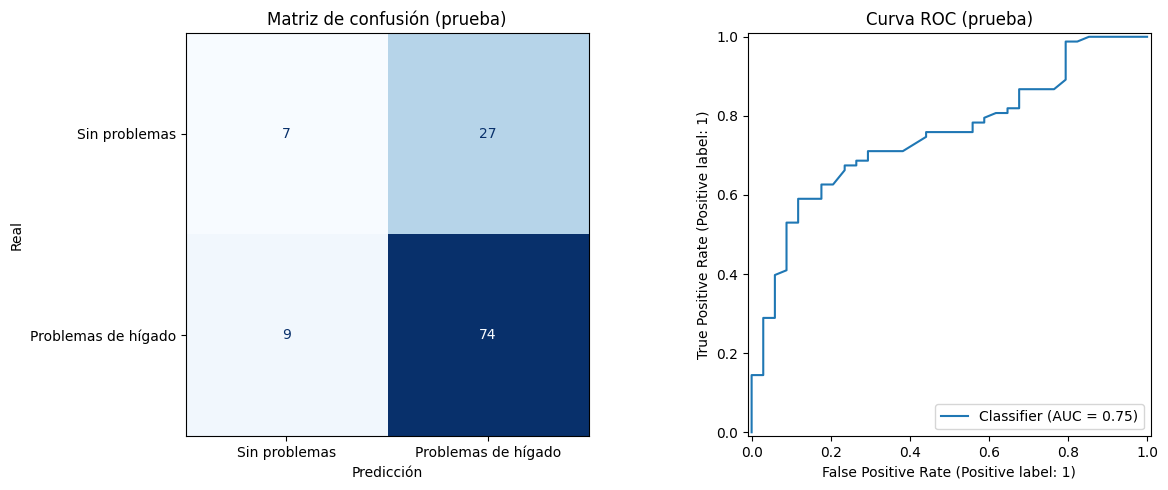

AUC-ROC en prueba: 0.749
Average precision en prueba: 0.887


In [16]:
fig, (ax_cm, ax_roc) = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Sin problemas", "Problemas de hígado"],
    cmap="Blues",
    colorbar=False,
    ax=ax_cm,
)
ax_cm.set_title("Matriz de confusión (prueba)")
ax_cm.set_xlabel("Predicción")
ax_cm.set_ylabel("Real")

RocCurveDisplay.from_predictions(y_test, y_proba, ax=ax_roc)
ax_roc.set_title("Curva ROC (prueba)")

plt.tight_layout()
plt.show()

print(f"AUC-ROC en prueba: {roc_auc_score(y_test, y_proba):.3f}")
print(f"Average precision en prueba: {average_precision_score(y_test, y_proba):.3f}")

**Lectura de la evaluación.** Sobre los 117 pacientes de prueba:

- **Clase 1 (83 enfermos):** recall 0,89 — detecta 74 de 83, con 9 falsos
  negativos (la heurística del baseline dejaba pasar 12) y precisión 0,733.
- **Clase 0 (34 sanos):** recall 0,21 — solo descarta a 7; 27 falsos
  positivos (el baseline tenía 22). El precio de priorizar la detección.
- **AUC-ROC 0,749** (baseline: 0,738 con su score ordinal) y **average
  precision 0,887** (baseline: 0,846): el ranking de pacientes del modelo es
  mejor que el de contar pruebas alteradas.
- **Accuracy 0,69**, otra vez indistinguible del piso tonto: con este
  desbalance sigue sin informar nada.

## ⚖️ Comparación contra el baseline

Reproducimos la heurística clínica del baseline (mismos cuatro umbrales de
laboratorio, misma imputación por mediana del entrenamiento) y el clasificador
dummy de clase mayoritaria, y evaluamos los tres sobre el mismo conjunto de
prueba con las métricas que definió el baseline: recall de enfermos como métrica
prioritaria, f1_macro como visión equilibrada, y AUC como calidad de ranking.

In [17]:
# umbrales clínicos de la heurística del baseline (sin calibrar con estos datos)
TOTAL_BILIRUBIN_REF_MAX = 1.2
ALT_REF_MAX = 56
AST_REF_MAX = 40
ALBUMIN_REF_MIN = 3.5
MIN_PRUEBAS_ALTERADAS = 1

cols_heuristica = [
    "Total_Bilirubin",
    "Alamine_Aminotransferase",
    "Aspartate_Aminotransferase",
    "Albumin",
]

preprocessor_heuristica = ColumnTransformer(
    transformers=[
        ("pruebas_hepaticas", SimpleImputer(strategy="median"), cols_heuristica),
    ],
    verbose_feature_names_out=False,
)
preprocessor_heuristica.set_output(transform="pandas")
preprocessor_heuristica.fit(x_train)
pruebas_test = preprocessor_heuristica.transform(x_test)

pruebas_alteradas = (
    (pruebas_test["Total_Bilirubin"] > TOTAL_BILIRUBIN_REF_MAX).astype(int)
    + (pruebas_test["Alamine_Aminotransferase"] > ALT_REF_MAX).astype(int)
    + (pruebas_test["Aspartate_Aminotransferase"] > AST_REF_MAX).astype(int)
    + (pruebas_test["Albumin"] < ALBUMIN_REF_MIN).astype(int)
)
y_pred_baseline = (pruebas_alteradas >= MIN_PRUEBAS_ALTERADAS).astype(int)

y_pred_dummy = DummyClassifier(strategy="most_frequent").fit(x_train, y_train).predict(x_test)
y_proba_dummy = np.full(len(x_test), y_train.mean())


def tabla_metricas(nombre, y_verdadero, y_etiqueta, y_score):
    # resumen de métricas de un modelo sobre el mismo conjunto de prueba
    return {
        "modelo": nombre,
        "recall_1": recall_score(y_verdadero, y_etiqueta),
        "especificidad": recall_score(y_verdadero, y_etiqueta, pos_label=0),
        "precision_1": precision_score(y_verdadero, y_etiqueta),
        "f1_1": f1_score(y_verdadero, y_etiqueta),
        "f1_macro": f1_score(y_verdadero, y_etiqueta, average="macro"),
        "auc": roc_auc_score(y_verdadero, y_score),
    }


comparacion = pd.DataFrame(
    [
        tabla_metricas("Dummy clase mayoritaria", y_test, y_pred_dummy, y_proba_dummy),
        tabla_metricas(
            "Baseline heurística clínica",
            y_test,
            y_pred_baseline,
            pruebas_alteradas / len(cols_heuristica),  # score ordinal del baseline
        ),
        tabla_metricas(f"AutoML: {familia_ganadora} + umbral", y_test, y_pred, y_proba),
    ]
).set_index("modelo")
comparacion.round(3)

,recall_1,especificidad,precision_1,f1_1,f1_macro,auc
modelo,,,,,,
Dummy clase mayoritaria,1.000,0.000,0.709,0.830,0.415,0.500
Baseline heurística clínica,0.855,0.353,0.763,0.807,0.610,0.738
AutoML: extra_tree + umbral,0.892,0.206,0.733,0.804,0.542,0.749


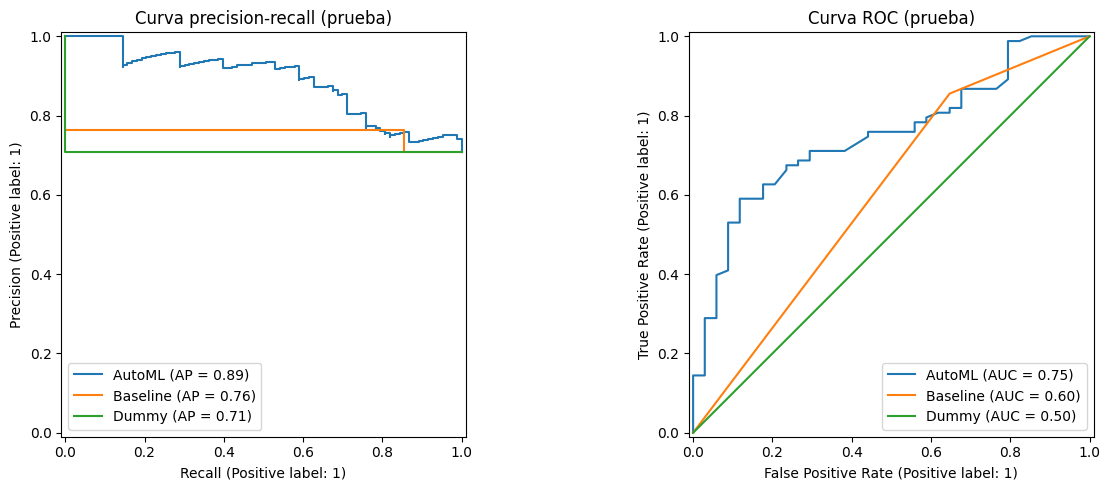

In [18]:
fig, (ax_pr, ax_roc_cmp) = plt.subplots(1, 2, figsize=(13, 5))

PrecisionRecallDisplay.from_predictions(y_test, y_proba, ax=ax_pr, name="AutoML")
PrecisionRecallDisplay.from_predictions(y_test, y_pred_baseline, ax=ax_pr, name="Baseline")
PrecisionRecallDisplay.from_predictions(y_test, y_proba_dummy, ax=ax_pr, name="Dummy")
ax_pr.set_title("Curva precision-recall (prueba)")

RocCurveDisplay.from_predictions(y_test, y_proba, ax=ax_roc_cmp, name="AutoML")
RocCurveDisplay.from_predictions(y_test, y_pred_baseline, ax=ax_roc_cmp, name="Baseline")
RocCurveDisplay.from_predictions(y_test, y_proba_dummy, ax=ax_roc_cmp, name="Dummy")
ax_roc_cmp.set_title("Curva ROC (prueba)")

plt.tight_layout()
plt.show()

### ¿Supera al baseline?

**Sí en lo que el problema prioriza; no en todo.** Con la métrica prioritaria
(recall de enfermos, el error costoso del tamizaje) y con la calidad de
ranking:

- **Recall: 0,892 vs 0,855** (+3,7 puntos): 74 enfermos detectados frente a
  71; tres pacientes menos que se van sin seguimiento, con el f1 de la clase 1
  prácticamente idéntico (0,804 vs 0,807).
- **AUC: 0,749 vs 0,738**, average precision 0,887 vs 0,846: el modelo ordena
  pacientes mejor que la regla.
- **En validación cruzada**, donde la comparación es más estable (10 folds vs
  117 pacientes), el macro F1 del ganador fue 0,654 frente a 0,567 del
  baseline: +8,7 puntos.

Y donde no gana, con honestidad:

- **f1_macro en prueba: 0,542 vs 0,610**, por la **especificidad: 0,206 vs
  0,353** (27 vs 22 falsos positivos). El umbral de 0,43, obligado por la
  regla de no bajar de 88 % de recall, empuja el punto de operación hacia la
  sensibilidad. El mismo modelo con el umbral por defecto 0,5 tendría mejor
  macro y especificidad (0,616 / 0,824 en validación) pero un recall
  inaceptable para el problema (0,55–0,60).

Con solo 117 pacientes de prueba, cada paciente mueve el recall casi un punto:
la mejora de 3 enfermos detectados es real pero modesta, y está dentro del
rango de variabilidad entre folds. La conclusión correcta es que **el AutoML
produce un modelo mejor como detector y con mejor ranking, a costa de más
falsas alarmas**, y que ninguna de las dos estrategias domina claramente a la
otra en este tamaño de muestra.

## 🔬 Sobreajuste y subajuste

Comparamos el desempeño del modelo final en tres planos: entrenamiento
(ajuste), validación cruzada (generalización interna, 10 folds estratificados
solo con train) y prueba (generalización real). Una brecha grande entre
entrenamiento y validación indicaría sobreajuste; un desempeño bajo en todos
los planos, subajuste.

In [19]:
cv_diagnostico = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)

diagnostico = pd.DataFrame(
    {
        "conjunto": ["Entrenamiento", "Validación (10 folds)", "Prueba"],
        "recall_1": [
            recall_score(y_train, modelo_final.predict(x_train)),
            cross_val_score(
                modelo_final, x_train, y_train, cv=cv_diagnostico, scoring="recall"
            ).mean(),
            recall_score(y_test, y_pred),
        ],
        "f1_macro": [
            f1_score(y_train, modelo_final.predict(x_train), average="macro"),
            cross_val_score(
                modelo_final, x_train, y_train, cv=cv_diagnostico, scoring="f1_macro"
            ).mean(),
            f1_score(y_test, y_pred, average="macro"),
        ],
    }
)
diagnostico_round = diagnostico.copy()
diagnostico_round[["recall_1", "f1_macro"]] = diagnostico_round[["recall_1", "f1_macro"]].round(3)
diagnostico_round

,conjunto,recall_1,f1_macro
0,Entrenamiento,0.900,0.601
1,Validación (10 folds),0.900,0.544
2,Prueba,0.892,0.542


**Lectura del diagnóstico.** Los tres planos son prácticamente idénticos:

- **Recall: 0,900 / 0,900 / 0,892** (entrenamiento / validación / prueba).
- **f1_macro: 0,601 / 0,544 / 0,542**.

No hay brecha entrenamiento-validación que delate sobreajuste: el modelo
ganador es deliberadamente pequeño (11 árboles de máximo 7 hojas) y el
balanceo de clases lo mantiene lejos de memorizar. Si acaso, muestra un
**subajuste moderado en la clase sana** — le cuesta separar a los pacientes
sin problemas, que es justamente donde el f1_macro pierde puntos. La
diferencia entre el macro F1 interno de la búsqueda (0,654 con umbral 0,5) y
el de este pipeline (0,544 con umbral 0,43) no es un problema de ajuste: es el
coste del punto de operación que exige el problema (priorizar detección).

## 📈 Curva de aprendizaje

Repetimos el análisis del baseline con el modelo final: desempeño en
entrenamiento y validación según el tamaño de la muestra (30 repeticiones por
tamaño con `ShuffleSplit`, banda sombreada = ±1 desviación). A diferencia de la
heurística —que no aprende nada—, aquí las curvas sí pueden informar si el
modelo se beneficia de más datos.

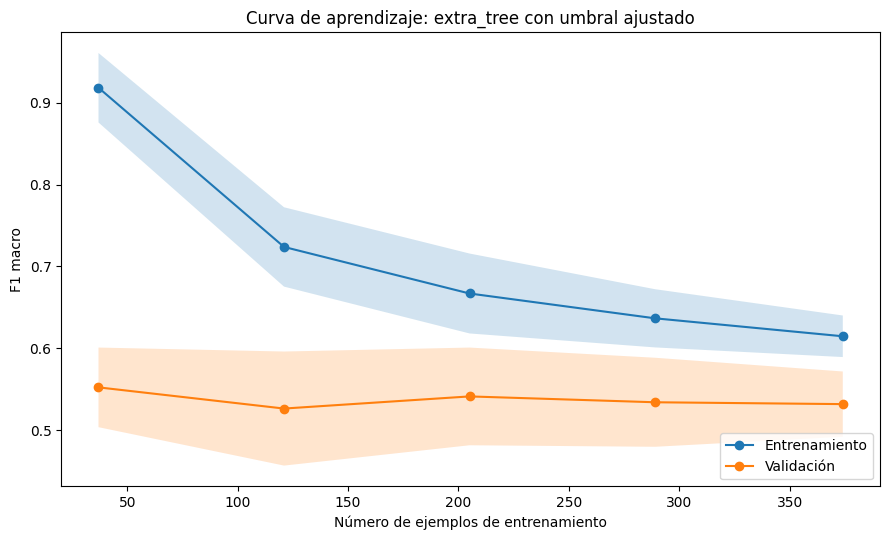

In [20]:
(
    tamanos_entrenamiento,
    scores_entrenamiento,
    scores_validacion,
    tiempos_fit,
    tiempos_score,
) = learning_curve(
    modelo_final,
    x_train,
    y_train,
    train_sizes=np.linspace(0.1, 1.0, 5),
    cv=ShuffleSplit(n_splits=30, test_size=0.2, random_state=123),
    scoring="f1_macro",
    n_jobs=-1,
    return_times=True,
)

media_entrenamiento = scores_entrenamiento.mean(axis=1)
std_entrenamiento = scores_entrenamiento.std(axis=1)
media_validacion = scores_validacion.mean(axis=1)
std_validacion = scores_validacion.std(axis=1)

fig, ax = plt.subplots(figsize=(9, 5.5))

ax.plot(tamanos_entrenamiento, media_entrenamiento, "o-", label="Entrenamiento")
ax.fill_between(
    tamanos_entrenamiento,
    media_entrenamiento - std_entrenamiento,
    media_entrenamiento + std_entrenamiento,
    alpha=0.2,
)
ax.plot(tamanos_entrenamiento, media_validacion, "o-", label="Validación")
ax.fill_between(
    tamanos_entrenamiento,
    media_validacion - std_validacion,
    media_validacion + std_validacion,
    alpha=0.2,
)
ax.set_xlabel("Número de ejemplos de entrenamiento")
ax.set_ylabel("F1 macro")
ax.set_title(f"Curva de aprendizaje: {familia_ganadora} con umbral ajustado")
ax.legend(loc="lower right")

plt.tight_layout()
plt.show()

**Lectura de la curva.** A diferencia del baseline (curvas planas por
diseño), aquí sí hay forma que interpretar:

- La curva de **entrenamiento** cae de 0,918 (37 ejemplos) a 0,615 (374): con
  pocas muestras los árboles las memorizan; al crecer el conjunto, el ajuste
  se vuelve honesto.
- La curva de **validación** es prácticamente plana alrededor de 0,53
  (±0,04–0,07): añadir datos dentro del rango disponible no mejoró el
  desempeño del modelo.
- Queda una **brecha moderada** (0,615 vs 0,532 con todo el entrenamiento):
  algo de varianza, pero contenida, coherente con el diagnóstico de la
  sección anterior.

La lectura práctica: con 585 registros el cuello de botella no es la capacidad
del modelo sino la cantidad de información; duplicar el dataset probablemente
aportaría más que probar arquitecturas más complejas.

## ⏱️ Escalabilidad

Con los tiempos registrados en la misma curva de aprendizaje: cómo crecen el
costo de entrenamiento y el de predicción con el tamaño del conjunto.

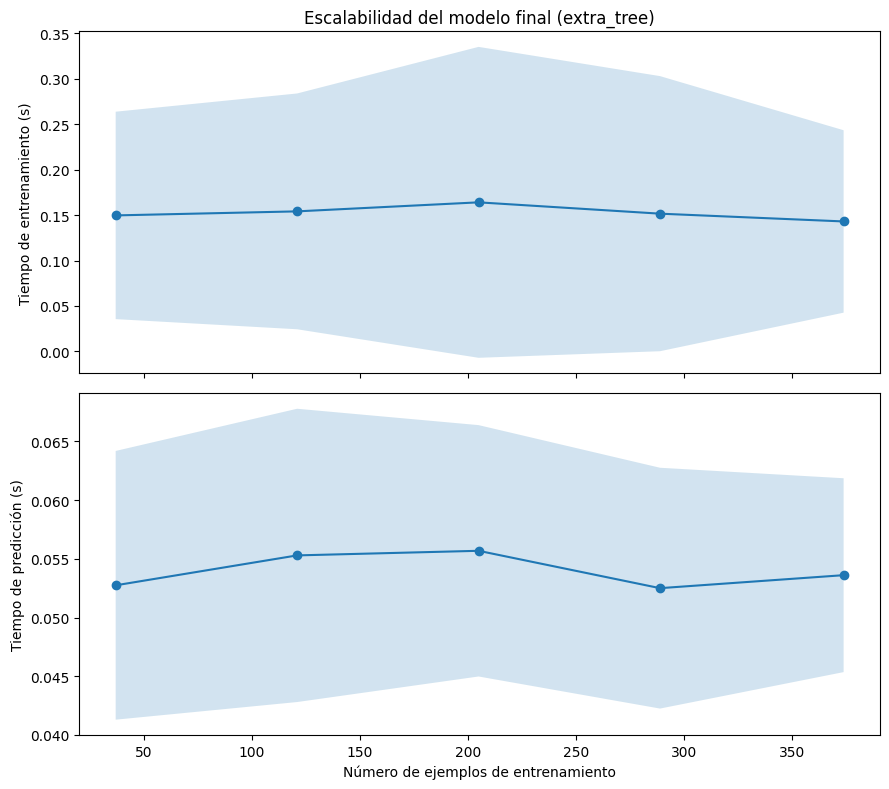

In [21]:
media_fit = tiempos_fit.mean(axis=1)
std_fit = tiempos_fit.std(axis=1)
media_score = tiempos_score.mean(axis=1)
std_score = tiempos_score.std(axis=1)

fig, (ax_fit, ax_score) = plt.subplots(2, 1, figsize=(9, 8), sharex=True)

ax_fit.plot(tamanos_entrenamiento, media_fit, "o-")
ax_fit.fill_between(tamanos_entrenamiento, media_fit - std_fit, media_fit + std_fit, alpha=0.2)
ax_fit.set_ylabel("Tiempo de entrenamiento (s)")
ax_fit.set_title(f"Escalabilidad del modelo final ({familia_ganadora})")

ax_score.plot(tamanos_entrenamiento, media_score, "o-")
ax_score.fill_between(
    tamanos_entrenamiento, media_score - std_score, media_score + std_score, alpha=0.2
)
ax_score.set_xlabel("Número de ejemplos de entrenamiento")
ax_score.set_ylabel("Tiempo de predicción (s)")

plt.tight_layout()
plt.show()

**Lectura de la escalabilidad.** El entrenamiento del modelo final cuesta
~0,14 s y la predicción ~0,05 s por fold de validación, ambos planos respecto
al tamaño del conjunto (11 árboles poco profundos: el costo casi no depende de
los datos). Para referencia, la búsqueda AutoML completa (149 configuraciones
de cinco familias) tardó menos de un minuto, una sola vez. A la escala de este proyecto —y de
cualquier panel hepático realista— el costo computacional del modelo es
despreciable; no hay ninguna razón de eficiencia para preferir el baseline.

## 🧭 Importancia de variables

El baseline documentó que sus dummies no permiten analizar importancia de
variables y dejó ese análisis para esta etapa. Con un ensemble de árboles
entrenado podemos hacerlo: la importancia por impureza indica cuánto contribuye
cada columna procesada (de las 13 del pipeline) a las decisiones del modelo.

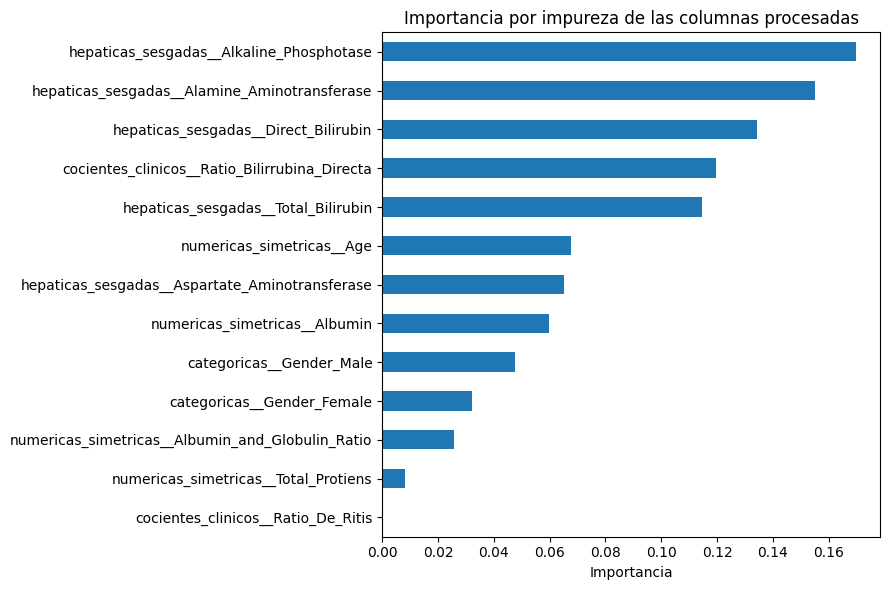

hepaticas_sesgadas__Total_Bilirubin              0.115
cocientes_clinicos__Ratio_Bilirrubina_Directa    0.120
hepaticas_sesgadas__Direct_Bilirubin             0.134
hepaticas_sesgadas__Alamine_Aminotransferase     0.155
hepaticas_sesgadas__Alkaline_Phosphotase         0.170
dtype: float64

In [22]:
pipeline_base.fit(x_train, y_train)

importancias = pd.Series(
    pipeline_base.named_steps["modelo"].feature_importances_,
    index=preprocessor.get_feature_names_out(),
).sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
importancias.plot(kind="barh", ax=ax)
ax.set_title("Importancia por impureza de las columnas procesadas")
ax.set_xlabel("Importancia")
plt.tight_layout()
plt.show()

importancias.tail(5).round(3)

**Lectura de las importancias.** Las cinco columnas más contributivas son la
fosfatasa alcalina (0,170), ALT (0,155), la bilirrubina directa (0,134), el
cociente bilirrubina directa/total creado en el Feature Engineering (0,120) y
la bilirrubina total (0,115). El ranking es coherente con el EDA —las
bilirrubinas y las enzimas de daño hepático eran las variables con mayor
señal— y valida la decisión de crear los cocientes clínicos: uno de ellos está
entre los cinco primeros aportes. La albúmina, central en la heurística del
baseline, aporta menos aquí: el modelo la usa combinada con el resto en vez de
como umbral aislado.

Dos cautelas metodológicas: la importancia por impureza tiende a favorecer a
las variables continuas con muchos valores distintos, y solo describe el modelo
ganador, no relaciones causales. El análisis con importancia por permutación y
SHAP queda anotado para la etapa de interpretación.

## 💾 Guardar el modelo entrenado

Persistimos el **pipeline completo** (preprocesamiento del Feature Engineering +
umbral + modelo) en formato `.joblib`, siguiendo la convención
`{dataset}-{algoritmo}-v{n}`. El archivo puede cargarse y aplicarse
directamente sobre pacientes nuevos con las 10 columnas originales, sin
reconstruir ningún paso del procesamiento.

In [23]:
MODELO_DIR = DATA_DIR / "06_models"
MODELO_DIR.mkdir(parents=True, exist_ok=True)
RUTA_MODELO = MODELO_DIR / f"pacientes_higado_clasificacion-{familia_ganadora}-v1.joblib"

joblib.dump(modelo_final, RUTA_MODELO, protocol=5)
print(f"Modelo guardado en: {RUTA_MODELO}")
print(f"Tamaño del archivo: {RUTA_MODELO.stat().st_size / 1024:.0f} KB")

Modelo guardado en: /workspaces/Pacientes_porblemas_higado_india/data/06_models/pacientes_higado_clasificacion-extra_tree-v1.joblib
Tamaño del archivo: 31 KB


In [24]:
# verificación: cargar el pipeline persistido y predecir un paciente nuevo
modelo_cargado = joblib.load(RUTA_MODELO)

paciente_nuevo = pd.DataFrame(
    {
        "Age": [52],
        "Gender": ["Unknown"],
        "Total_Bilirubin": [2.1],
        "Direct_Bilirubin": [0.9],
        "Alkaline_Phosphotase": [280.0],
        "Alamine_Aminotransferase": [45.0],
        "Aspartate_Aminotransferase": [38.0],
        "Total_Protiens": [6.1],
        "Albumin": [2.9],
        "Albumin_and_Globulin_Ratio": [0.8],
    }
)

prediccion = modelo_cargado.predict(paciente_nuevo)[0]
probabilidad = modelo_cargado.predict_proba(paciente_nuevo)[0, 1]
print(f"Predicción del paciente nuevo: {prediccion} (probabilidad de clase 1: {probabilidad:.3f})")
assert (modelo_cargado.predict(x_test) == y_pred).all()
print("El pipeline cargado reproduce exactamente las predicciones de la evaluación")

Predicción del paciente nuevo: 1 (probabilidad de clase 1: 0.460)
El pipeline cargado reproduce exactamente las predicciones de la evaluación


El pipeline completo quedó persistido en
`data/06_models/pacientes_higado_clasificacion-extra_tree-v1.joblib` (31 KB):
preprocesamiento del Feature Engineering, extra trees balanceado y umbral de
0,43, todo dentro de un solo objeto scikit-learn.

La verificación de carga cumplió tres comprobaciones: el archivo se carga sin
errores, reproduce exactamente las predicciones de la evaluación y procesa un
paciente nuevo (las 10 columnas originales, incluso con un género desconocido
que el one-hot maneja sin romperse) entregando predicción 1 con probabilidad
0,460 — por encima del umbral interno, como corresponde a un paciente con
bilirrubina alta y albúmina baja.

## 📊 Interpretación de resultados

**Qué se hizo.** Un buscador AutoML (FLAML) comparó cinco familias de modelos
—regresión logística, random forest, extra trees, k-vecinos y LightGBM— con
validación cruzada estratificada de 5 folds usando únicamente el conjunto de
entrenamiento, sobre las 13 columnas del pipeline de Feature Engineering. La
familia ganadora (extra trees con balanceo de clases) se reconstruyó como
estimador scikit-learn puro, se le ajustó un umbral de decisión sobre el
propio entrenamiento (regla del baseline: máximo f1_macro con recall ≥ 0,88) y
el resultado se evaluó una única vez sobre la prueba.

**Qué resultado dio.** El modelo final detecta al 89 % de los enfermos de
prueba (baseline: 86 %) con un ranking claramente mejor (AUC 0,749 vs 0,738;
AP 0,887 vs 0,846), a costa de más falsas alarmas (especificidad 0,21 vs
0,35). En validación cruzada, donde las comparaciones son más fiables que en
117 pacientes, su macro F1 superó al del baseline por 8,7 puntos (0,654 vs
0,567) y cuatro de las cinco familias evaluadas ya lo superaban: la referencia
heurística, aunque sólida, no resiste frente a cualquier modelo supervisado
decente.

**Qué significa.** Para el objetivo de esta etapa —superar la referencia del
baseline— el AutoML cumplió: el modelo seleccionado es mejor donde el problema
lo exige (detección y ranking) y el coste es operativo (más seguimientos
innecesarios), no clínico. El diagnóstico de sobreajuste es tranquilo
(entrenamiento, validación y prueba casi idénticos) y las curvas señalan que
el límite actual es la cantidad de datos, no la complejidad del modelo.

## 📈 Conclusiones

1. **La selección automatizada funcionó y fue barata**: menos de un minuto de búsqueda
   encontraron un modelo que mejora la referencia del baseline en la métrica
   prioritaria del problema, sin iteración manual sobre algoritmos ni
   hiperparámetros.
2. **El manejo del desbalance resultó decisivo.** El buscador eligió por sí
   solo `class_weight="balanced"` para la familia ganadora, confirmando la
   recomendación del baseline: en un problema 71/29, el balanceo no es un
   detalle.
3. **Mejora real pero acotada en prueba.** Tres enfermos más detectados que el
   baseline y mejor ranking; a cambio, cinco falsos positivos más. Con 117
   pacientes de prueba, las diferencias de pocas unidades mueven puntos
   enteros: la honestidad obliga a llamarlo una mejora moderada, no un salto.
4. **El punto de operación importa tanto como el modelo.** El mismo extra
   trees con umbral 0,5 tendría mejor f1_macro y especificidad, pero perdería
   al 40 % de los enfermos: inaceptable en tamizaje. Fijar la regla de umbral
   con los criterios del baseline, antes de mirar la prueba, fue lo que
   mantiene coherente la comparación.
5. **Queda un artefacto utilizable.** El pipeline completo (preprocesamiento +
   modelo + umbral) está guardado en `.joblib`, verificado sobre datos nuevos
   y listo para las etapas de interpretación y despliegue.

## 🧑‍🔬 Recomendaciones

1. **Mantener el recall como métrica de vigilancia** en las siguientes
   iteraciones: cualquier cambio (features, modelo, umbral) debería conservar
   o mejorar el 89 % de detección actual; las ganancias de especificidad no
   deben pagarse con enfermos sin detectar.
2. **Trabajar la especificidad como siguiente objetivo.** El margen está en
   los 27 falsos positivos: un segundo escalón del flujo (por ejemplo, prueba
   confirmatoria para los casos dudosos) o más datos de pacientes sanos
   reducirían las alarmas sin tocar el modelo.
3. **Recopilar más datos antes de subir la complejidad.** La curva de
   aprendizaje es plana y cuatro de cinco familias empatan en centésimas:
   más registros —especialmente de la clase minoritaria— valen más que un
   modelo más sofisticado.
4. **Conservar la disciplina de esta etapa en adelante:** selección y umbral
   solo con el entrenamiento, prueba intocada hasta la evaluación final, todo
   dentro de pipelines.
5. **Verificar la estabilidad del ganador entre ejecuciones** si el pipeline
   se reentrena en producción: la búsqueda de FLAML puede variar en detalles
   (11 vs 15 árboles) aunque la familia y el nivel de desempeño fueron
   estables; fijar la configuración guardada evita derivas.

## 💡 Propuestas para la siguiente etapa

- **Registro de experimentos** (MLflow): trackear parámetros, métricas y
  artefactos de cada corrida de entrenamiento, incluyendo las búsquedas
  AutoML, para tener trazabilidad completa del ciclo de modelado.
- **Validación del pipeline** (chequeos de integridad y de distribuciones):
  verificar fugas de datos, deriva entre entrenamiento y producción, y consistencia del
  preprocesamiento de forma sistemática antes del despliegue.
- **Importancia por permutación y SHAP** sobre el modelo ganador: complementan
  la importancia por impureza calculada aquí y permiten explicaciones por
  paciente, necesarias en un contexto clínico.
- **Calibración de probabilidades** (`CalibratedClassifierCV`): el umbral 0,43
  funciona como corte operativo, pero las probabilidades del ensemble no están
  calibradas; calibrarlas habilitaría comunicación clínica de riesgo.
- **Ensembles y segunda pasada de AutoML** con más presupuesto o
  `ensemble=True` de FLAML, solo si se consigue más data: con 585 registros el
  margen esperado es pequeño.
- **Comparativa por subgrupos** (género, edad): evaluar si el modelo se
  comporta igual en mujeres (24 % de la muestra), un análisis que el EDA dejó
  anotado y que ninguna etapa ha cerrado aún.

## 📖 Referencias

- Documentación de FLAML (Microsoft):
  <https://microsoft.github.io/FLAML/>
- FLAML como componente de un pipeline de scikit-learn:
  <https://microsoft.github.io/FLAML/docs/Use-Cases/Task-Oriented-AutoML/>
- Documentación de `FixedThresholdClassifier`:
  <https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.FixedThresholdClassifier.html>
- Documentación de scikit-learn sobre curvas de aprendizaje:
  <https://scikit-learn.org/stable/modules/learning_curve.html>
- Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow (2ª edición),
  Aurélien Géron — capítulo 2, sobre selección de modelos y pipelines.
- Dataset ILPD (Indian Liver Patient Dataset):
  <https://archive.ics.uci.edu/dataset/225/ilpd+indian+liver+patient+dataset>